In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64  # Import base64 library
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import pymongo
import os
from tensorflow.keras.utils import Sequence, to_categorical
import gc  # Garbage Collector
from tqdm import tqdm  # Progress bar

2024-12-03 09:58:09.839046: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-03 09:58:10.567428: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Funktion zur Überwachung des Speicherverbrauchs
def check_memory_usage(threshold=90):
    memory = psutil.virtual_memory()
    if memory.percent > threshold:
        print(f"Warnung: Speicherverbrauch bei {memory.percent}%. Programm wird gestoppt.")
        raise MemoryError("Speicherverbrauch zu hoch")

In [3]:
# Load and Merge Data

# Function to load data from MongoDB
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    # Load data
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    # Convert to DataFrames
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    # Merge DataFrames
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                         left_on='fingerprintId', 
                         right_on='_id', 
                         suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Load data
merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")

Gesamtdatensatz enthält 2000000 Einträge.


In [4]:
# Preprocess Data

# Function to process images in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Convert image to RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalize to values between 0 and 1
        return image_array
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

# Function to extract images and labels from DataFrame
def extract_images_from_df(df, example_user_id):
    images = []
    labels = []
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Lade Bilder"):
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

# Example user ID
example_user_id = 'benutzername_1'

# Create DataFrames for each user
user_ids = merged_df['username'].unique()
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Sample data for the example user
user_df = user_dfs[example_user_id].sample(n=15000, random_state=42)

# Add negative examples and limit
negative_df = pd.concat([user_dfs[user_id] for user_id in user_ids if user_id != example_user_id])
negative_df = negative_df.sample(n=15000, random_state=42)

# Split into Train/Val/Test sets (70% Train, 20% Val, 10% Test)
train_df, test_df = train_test_split(pd.concat([user_df, negative_df]), test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2222, random_state=42)  # 0.2222 * 0.9 ≈ 0.2

# Process image data
try:
    X_train, y_train = extract_images_from_df(train_df, example_user_id)
    X_val, y_val = extract_images_from_df(val_df, example_user_id)
    X_test, y_test = extract_images_from_df(test_df, example_user_id)
except Exception as e:
    print(f"Fehler bei der Bilddatenverarbeitung: {e}")

# Free up memory
gc.collect()

Lade Bilder: 100%|██████████| 3000/3000 [00:02<00:00, 1386.29it/s]


0

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 128)       0

2024-12-03 10:01:58.865014: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-03 10:01:58.905095: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-03 10:01:58.905397: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Epoch 1/50


2024-12-03 10:03:37.442714: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2024-12-03 10:03:37.914790: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2024-12-03 10:03:38.019752: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x74dfbc1ef820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-12-03 10:03:38.019783: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2024-12-03 10:03:38.089504: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-12-03 10:03:38.441664: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.

1313/1313 [==============================] - ETA: 0s - loss: 0.2850 - accuracy: 0.8953

2024-12-03 10:03:54.253807: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 3612672000 exceeds 10% of free system memory.


1313/1313 [==============================] - 24s 14ms/step - loss: 0.2850 - accuracy: 0.8953 - val_loss: 0.2305 - val_accuracy: 0.9225
Epoch 2/50
1313/1313 [==============================] - 14s 11ms/step - loss: 0.2467 - accuracy: 0.9179 - val_loss: 0.2266 - val_accuracy: 0.9227
Epoch 3/50
1313/1313 [==============================] - 14s 11ms/step - loss: 0.2352 - accuracy: 0.9210 - val_loss: 0.2350 - val_accuracy: 0.9212
Epoch 4/50
1313/1313 [==============================] - 14s 11ms/step - loss: 0.2388 - accuracy: 0.9190 - val_loss: 0.2331 - val_accuracy: 0.9215
Epoch 5/50
1313/1313 [==============================] - 14s 11ms/step - loss: 0.2353 - accuracy: 0.9203 - val_loss: 0.2275 - val_accuracy: 0.9230
Epoch 6/50
1313/1313 [==============================] - 14s 11ms/step - loss: 0.2306 - accuracy: 0.9211 - val_loss: 0.2261 - val_accuracy: 0.9228
Epoch 7/50
1313/1313 [==============================] - 14s 11ms/step - loss: 0.2290 - accuracy: 0.9211 - val_loss: 0.2324 - val_accura

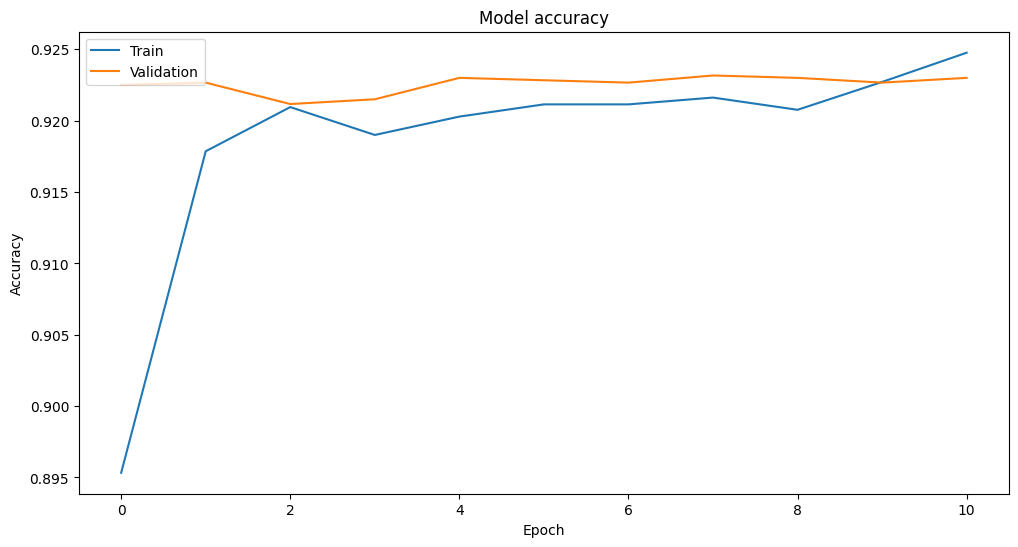

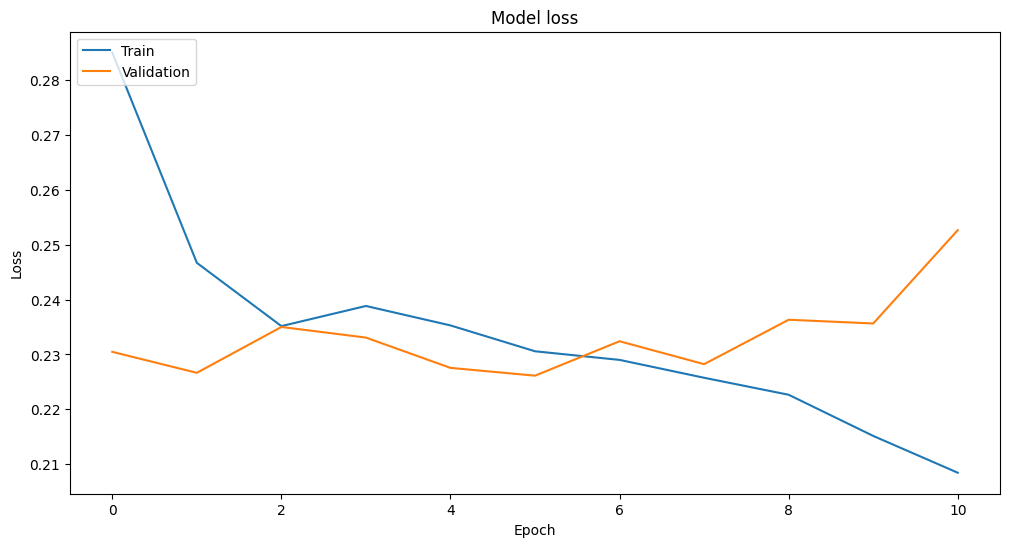

/usr/local/lib/python3.8/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [5]:
# Define CNN Model
def create_model_with_probabilities(input_shape):
    model = Sequential()
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))  # Sigmoid für prozentuale Vorhersagen
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Beispielhafte Eingabeform
input_shape = (224, 224, 3)  # Passen Sie dies an Ihre Daten an
model_with_probabilities = create_model_with_probabilities(input_shape)

# Display the model summary
model_with_probabilities.summary()

# Train the Model

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history_prob = model_with_probabilities.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    batch_size=16  # Passe die Batch-Größe an
)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history_prob.history['accuracy'])
plt.plot(history_prob.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history_prob.history['loss'])
plt.plot(history_prob.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Save the model
model_with_probabilities.save(f'{example_user_id}_classification_model.h5')

94/94 [==============================] - 1s 9ms/step - loss: 0.2370 - accuracy: 0.9213
Test Loss: 0.23702934384346008
Test Accuracy: 0.9213333129882812
94/94 [==============================] - 1s 7ms/step
              precision    recall  f1-score   support

           0       1.00      0.84      0.91      1470
           1       0.87      1.00      0.93      1530

    accuracy                           0.92      3000
   macro avg       0.93      0.92      0.92      3000
weighted avg       0.93      0.92      0.92      3000



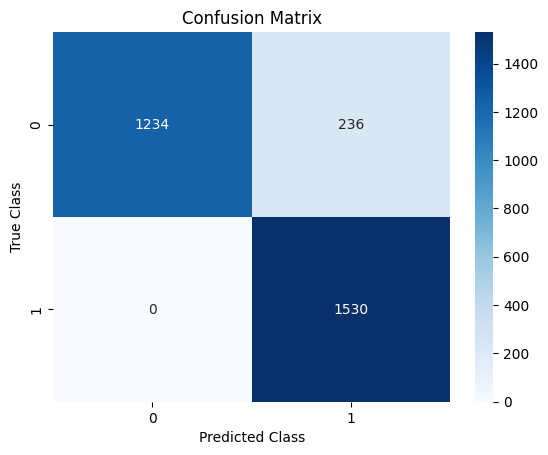

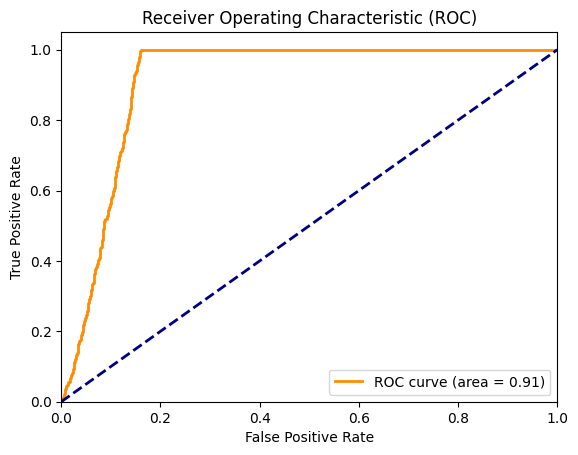

In [6]:
# Evaluate the Model

# Evaluate the model on the test data
loss, accuracy = model_with_probabilities.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

# Make predictions on the test data
y_pred = model_with_probabilities.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

# Print classification report
print(classification_report(y_test, y_pred_classes))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

4/4 [==============================] - 0s 23ms/step


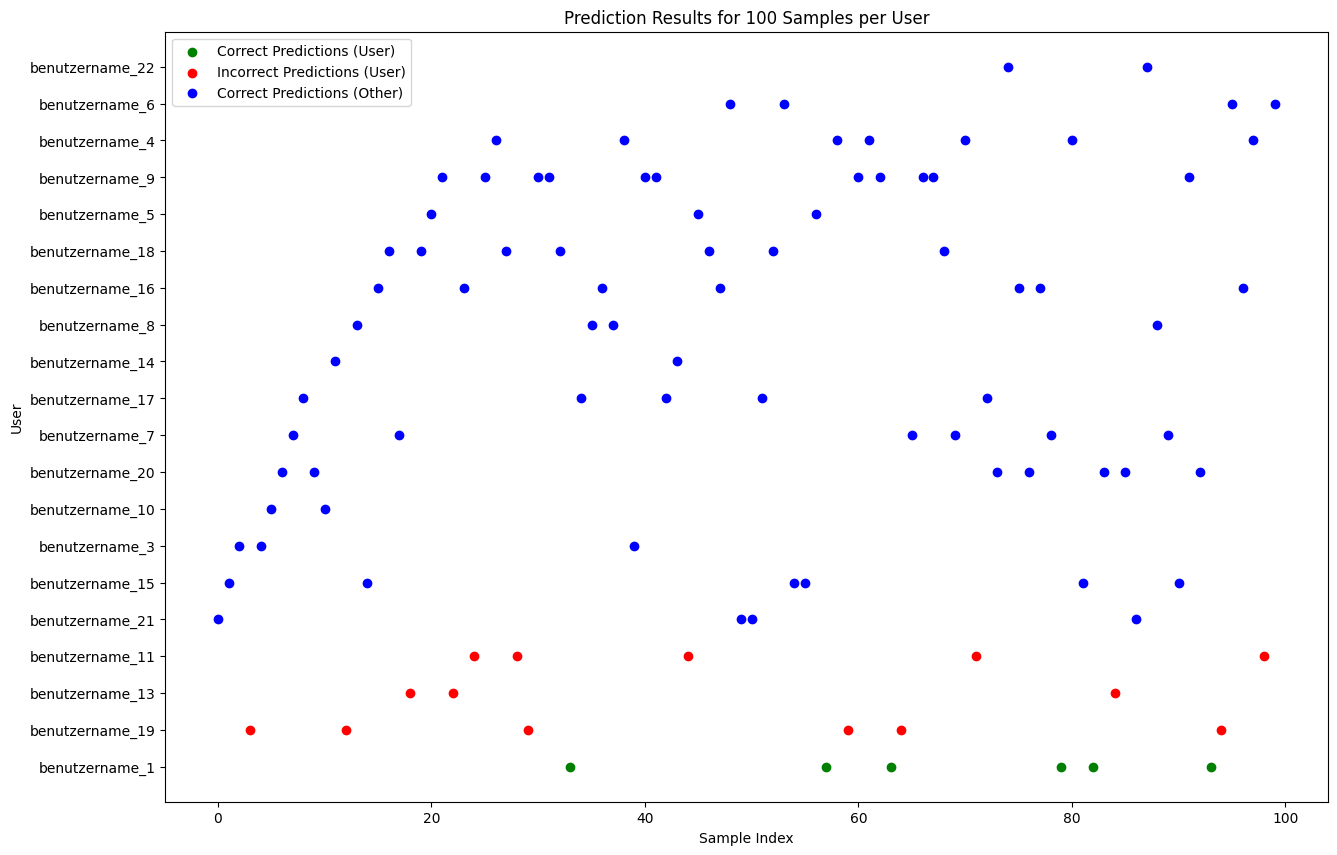

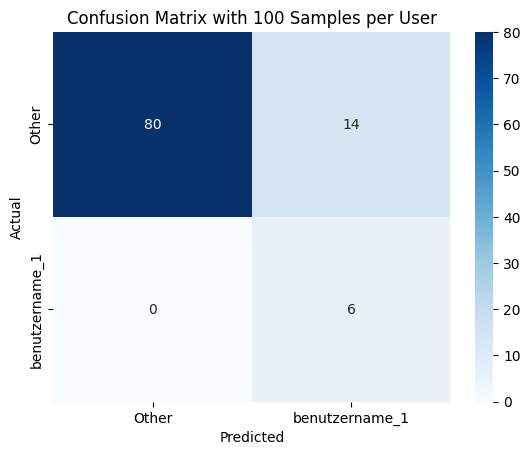

Accuracy: 86.00%
              precision    recall  f1-score   support

       False       1.00      0.85      0.92        94
        True       0.30      1.00      0.46         6

    accuracy                           0.86       100
   macro avg       0.65      0.93      0.69       100
weighted avg       0.96      0.86      0.89       100



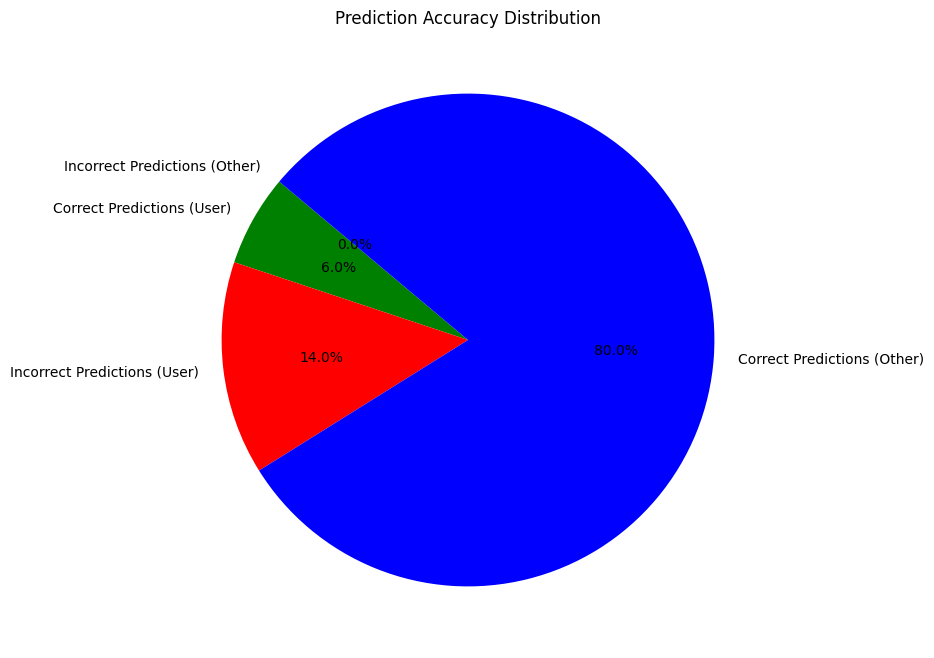

In [7]:
# Load the model
model = load_model('user_classification_model.h5')

# Function to prepare images from the dataframe
def prepare_images(df, num_samples):
    images = []
    labels = []
    sampled_df = df.sample(n=num_samples, random_state=42)
    for _, row in sampled_df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(row['username'])
    return np.array(images), np.array(labels)

# Test with 1000 samples from random users
num_samples = 100
X_test_users, y_test_users = prepare_images(merged_df, num_samples)

# Get predictions
y_pred = model.predict(X_test_users)
y_pred_labels = [example_user_id if pred > 0.5 else 'other_user' for pred in y_pred.flatten()]

# Create a DataFrame for visualization
results_df = pd.DataFrame({
    'Actual User': y_test_users,
    'Predicted User': y_pred_labels
})

# Plotting the results
def plot_prediction_results(results_df, num_samples, example_user_id):
    plt.figure(figsize=(15, 10))
    correct_predictions = results_df[(results_df['Actual User'] == example_user_id) & (results_df['Predicted User'] == example_user_id)]
    incorrect_predictions = results_df[(results_df['Actual User'] != example_user_id) & (results_df['Predicted User'] == example_user_id)]
    other_correct_predictions = results_df[(results_df['Actual User'] != example_user_id) & (results_df['Predicted User'] != example_user_id)]
    
    plt.scatter(correct_predictions.index, correct_predictions['Actual User'], color='green', label='Correct Predictions (User)')
    plt.scatter(incorrect_predictions.index, incorrect_predictions['Actual User'], color='red', label='Incorrect Predictions (User)')
    plt.scatter(other_correct_predictions.index, other_correct_predictions['Actual User'], color='blue', label='Correct Predictions (Other)')
    
    plt.xlabel('Sample Index')
    plt.ylabel('User')
    plt.title(f'Prediction Results for {num_samples} Samples per User')
    plt.legend()
    plt.show()

plot_prediction_results(results_df, num_samples, example_user_id)

# Confusion Matrix
conf_matrix = confusion_matrix(results_df['Actual User'] == example_user_id, results_df['Predicted User'] == example_user_id)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Other', example_user_id], yticklabels=['Other', example_user_id])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix with {num_samples} Samples per User')
plt.show()

# Accuracy
accuracy = accuracy_score(results_df['Actual User'] == example_user_id, results_df['Predicted User'] == example_user_id)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Classification Report
print(classification_report(results_df['Actual User'] == example_user_id, results_df['Predicted User'] == example_user_id))

# Pie Chart for Prediction Accuracy
def plot_pie_chart(results_df, example_user_id):
    total_samples = len(results_df)
    correct_predictions = len(results_df[(results_df['Actual User'] == example_user_id) & (results_df['Predicted User'] == example_user_id)])
    incorrect_predictions = len(results_df[(results_df['Actual User'] != example_user_id) & (results_df['Predicted User'] == example_user_id)])
    other_correct_predictions = len(results_df[(results_df['Actual User'] != example_user_id) & (results_df['Predicted User'] != example_user_id)])
    other_incorrect_predictions = len(results_df[(results_df['Actual User'] == example_user_id) & (results_df['Predicted User'] != example_user_id)])
    
    labels = ['Correct Predictions (User)', 'Incorrect Predictions (User)', 'Correct Predictions (Other)', 'Incorrect Predictions (Other)']
    sizes = [correct_predictions, incorrect_predictions, other_correct_predictions, other_incorrect_predictions]
    colors = ['green', 'red', 'blue', 'orange']
    
    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
    plt.title('Prediction Accuracy Distribution')
    plt.show()

plot_pie_chart(results_df, example_user_id)

In [8]:
# Load the model
model = load_model(f'{example_user_id}_classification_model.h5')

# Function to prepare images from the dataframe
def prepare_images(df, num_samples):
    images = []
    labels = []
    sampled_df = df.sample(n=num_samples, random_state=42)
    for _, row in sampled_df.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(row['username'])
    return np.array(images), np.array(labels)

# Test with 10,000 samples from random users
num_samples = 10000
X_test_users, y_test_users = prepare_images(merged_df, num_samples)

# Get predictions
y_pred = model.predict(X_test_users)
y_pred_labels = [example_user_id if pred > 0.5 else 'other_user' for pred in y_pred.flatten()]

# Create a DataFrame for visualization
results_df = pd.DataFrame({
    'Actual User': y_test_users,
    'Predicted User': y_pred_labels
})

# Plotting the results
def plot_prediction_results(results_df, num_samples, example_user_id):
    plt.figure(figsize=(15, 10))
    correct_predictions = results_df[(results_df['Actual User'] == example_user_id) & (results_df['Predicted User'] == example_user_id)]
    incorrect_predictions = results_df[(results_df['Actual User'] != example_user_id) & (results_df['Predicted User'] == example_user_id)]
    other_correct_predictions = results_df[(results_df['Actual User'] != example_user_id) & (results_df['Predicted User'] != example_user_id)]
    
    plt.scatter(correct_predictions.index, correct_predictions['Actual User'], color='green', label='Correct Predictions (User)')
    plt.scatter(incorrect_predictions.index, incorrect_predictions['Actual User'], color='red', label='Incorrect Predictions (User)')
    plt.scatter(other_correct_predictions.index, other_correct_predictions['Actual User'], color='blue', label='Correct Predictions (Other)')
    
    plt.xlabel('Sample Index')
    plt.ylabel('User')
    plt.title(f'Prediction Results for {num_samples} Samples per User')
    plt.legend()
    plt.show()

plot_prediction_results(results_df, num_samples, example_user_id)

# Confusion Matrix
conf_matrix = confusion_matrix(results_df['Actual User'] == example_user_id, results_df['Predicted User'] == example_user_id)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Other', example_user_id], yticklabels=['Other', example_user_id])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix with {num_samples} Samples per User')
plt.show()

# Accuracy
accuracy = accuracy_score(results_df['Actual User'] == example_user_id, results_df['Predicted User'] == example_user_id)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Classification Report
print(classification_report(results_df['Actual User'] == example_user_id, results_df['Predicted User'] == example_user_id))

# Pie Chart for Prediction Accuracy
def plot_pie_chart(results_df, example_user_id):
    total_samples = len(results_df)
    correct_predictions = len(results_df[(results_df['Actual User'] == example_user_id) & (results_df['Predicted User'] == example_user_id)])
    incorrect_predictions = len(results_df[(results_df['Actual User'] != example_user_id) & (results_df['Predicted User'] == example_user_id)])
    other_correct_predictions = len(results_df[(results_df['Actual User'] != example_user_id) & (results_df['Predicted User'] != example_user_id)])
    other_incorrect_predictions = len(results_df[(results_df['Actual User'] == example_user_id) & (results_df['Predicted User'] != example_user_id)])
    
    labels = ['Correct Predictions (User)', 'Incorrect Predictions (User)', 'Correct Predictions (Other)', 'Incorrect Predictions (Other)']
    sizes = [correct_predictions, incorrect_predictions, other_correct_predictions, other_incorrect_predictions]
    colors = ['green', 'red', 'blue', 'orange']
    
    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
    plt.title('Prediction Accuracy Distribution')
    plt.show()

plot_pie_chart(results_df, example_user_id)

2024-12-03 10:07:13.688043: W tensorflow/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 6021120000 exceeds 10% of free system memory.
2024-12-03 10:07:49.933863: W tensorflow/tsl/framework/bfc_allocator.cc:485] Allocator (GPU_0_bfc) ran out of memory trying to allocate 5.61GiB (rounded to 6021120000)requested by op _EagerConst
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2024-12-03 10:07:49.933917: I tensorflow/tsl/framework/bfc_allocator.cc:1039] BFCAllocator dump for GPU_0_bfc
2024-12-03 10:07:49.933939: I tensorflow/tsl/framework/bfc_allocator.cc:1046] Bin (256): 	Total Chunks: 81, Chunks in use: 81. 20.2KiB allocated for chunks. 20.2KiB in use in bin. 3.7KiB client-requested in use in bin.
2024-12-03 10:07:49.933956: I tensorflow/tsl/framework/bfc_allocator.cc:1046] Bin (512): 	Total Chunks: 27, Chunks in use: 27. 14

InternalError: Failed copying input tensor from /job:localhost/replica:0/task:0/device:CPU:0 to /job:localhost/replica:0/task:0/device:GPU:0 in order to run _EagerConst: Dst tensor is not initialized.

In [ ]:
# Speicher freigeben
gc.collect()
K.clear_session()